# AutoEncoder
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/TheRedElement/LStein/blob/main/data/auto_encoder_hypsearch.ipynb)

If you run this notebook in [google colab](https://colab.google/), you should not need to install anything else.
You might, however, need to restart your session to have the required versions of [matplotlib](https://matplotlib.org/), [numpy](https://numpy.org/), [Plotly](https://plotly.com/python/) ready.

Very simple AutoEncoder (AE) for encoding MNIST handwritten digits.
Used to generate dataset for demonstrating LStein applied to hyperparameter searches.

In [ ]:
#installs
#!pip3 install <pkg>

In [ ]:
#%%imports
import matplotlib.animation as manimation
import matplotlib.pyplot as plt
from matplotlib import rc       #for embedding animations in colab
import numpy as np
import polars as pl
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets

In [ ]:
#%%hyperparams
hypercombs = [
    (32, 20, 128,  1e-3),
    (4,  20, 1024, 1e-6),
    (4,  20, 16,   1e-6),
    (128,20, 16,   1e-3),
    (128,20, 128,  1e-1),
]
dhidden, nepochs, batchsize, lr = hypercombs[0]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

fn = f"./data/autoencoder_dhidden{dhidden}_batchsize{batchsize}_lr{lr*10000:05.0f}.csv"
print(fn)

./data/autoencoder_dhidden4_batchsize1024_lr00000.csv


In [ ]:
#%%load data
tr_data = datasets.MNIST(root="data", train=True, download=True)
labels = tr_data.targets   #labels
tr_data = tr_data.data/255    #normalize pixel values
tr_data = tr_data.reshape(-1, 28*28)

val = datasets.MNIST(root="data", train=False, download=True)
val_labels = val.targets
val_data = val.data/255
val_data = val_data.reshape(-1, 28*28)

train_loader = DataLoader(dataset=tr_data, batch_size=batchsize, shuffle=True, drop_last=True)



torch.Size([60000, 784])


In [ ]:
class AE(nn.Module):

    def __init__(self,
        d_in, d_hidden, d_latent,
        ):

        super(AE, self).__init__()

        self.d_in = d_in
        self.d_hidden = d_hidden
        self.d_latent = d_latent

        self.enc = nn.Sequential(
            nn.Linear(self.d_in, self.d_hidden),
            nn.ReLU(),
            nn.Linear(self.d_hidden, self.d_latent),
        )

        self.dec = nn.Sequential(
            nn.Linear(self.d_latent, self.d_hidden),
            nn.ReLU(),
            nn.Linear(self.d_hidden, self.d_in),
            nn.Sigmoid(),
        )

        return

    def encode(self,x):
        return self.enc(x)

    def decode(self,z):
        return self.dec(z)

    def forward(self,x):
        z = self.encode(x)
        x_rec = self.decode(z)
        return x_rec


In [ ]:
def train(model, optimizer, epochs, device):
    model.train()
    #init for outputs
    losses_tr = []
    losses_va = []
    durations = []
    latent_space = torch.empty(epochs, val_data.size(0), 2)
    targets = torch.empty(epochs, val_data.size(0))

    #train
    for epoch in range(epochs):
        ts = time.time()    #starting time to compute duration of epoch
        total_loss = 0

        for batch_idx, x in enumerate(train_loader):
            #reshape
            x = x.view(batchsize, model.d_in).to(device)

            #reset gradients
            optimizer.zero_grad()

            #forward pass
            x_rec = model(x)
            loss = F.binary_cross_entropy(x_rec, x, reduction='sum')

            #add to output
            total_loss += loss.item()

            #backward pass
            loss.backward()
            optimizer.step()    #update params

        #validate
        model.eval()    #set into validation mode
        losses_va.append(F.binary_cross_entropy(model(val_data.to(device)), val_data.to(device), reduction='sum').item()/val_data.size(0))
        latent_space[epoch,:] = model.encode(val_data.to(device))
        model.train()   #set into training mode

        te = time.time()    #end time to compute duration of epoch

        #store interesting quantities
        durations.append(te - ts)
        losses_tr.append(total_loss/(batch_idx*batchsize))

        #summarize epoch
        print(f"\tEpoch {epoch + 1} \tAverage Train Loss: {losses_tr[epoch]:9.3f} \tAverage Validation Loss: {losses_va[epoch]:9.3f} \tDuration:  {te - ts:9.4f} s")
    return losses_tr, losses_va, durations, latent_space


In [ ]:
#%%training
model = AE(tr_data.size(1), dhidden, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
model.to(device)

loss_tr, loss_va, duration, latent_space = train(model, optimizer, nepochs, device)


	Epoch 1 	Average Train Loss:   563.765 	Average Validation Loss:   554.003 	Duration:     0.3898 s
	Epoch 2 	Average Train Loss:   563.727 	Average Validation Loss:   553.963 	Duration:     0.3966 s
	Epoch 3 	Average Train Loss:   563.688 	Average Validation Loss:   553.924 	Duration:     0.5773 s
	Epoch 4 	Average Train Loss:   563.647 	Average Validation Loss:   553.884 	Duration:     0.4808 s
	Epoch 5 	Average Train Loss:   563.608 	Average Validation Loss:   553.845 	Duration:     0.4904 s
	Epoch 6 	Average Train Loss:   563.567 	Average Validation Loss:   553.806 	Duration:     0.4969 s
	Epoch 7 	Average Train Loss:   563.527 	Average Validation Loss:   553.767 	Duration:     0.3695 s
	Epoch 8 	Average Train Loss:   563.489 	Average Validation Loss:   553.728 	Duration:     0.3664 s
	Epoch 9 	Average Train Loss:   563.450 	Average Validation Loss:   553.689 	Duration:     0.3589 s
	Epoch 10 	Average Train Loss:   563.408 	Average Validation Loss:   553.651 	Duration:     0.3504 s

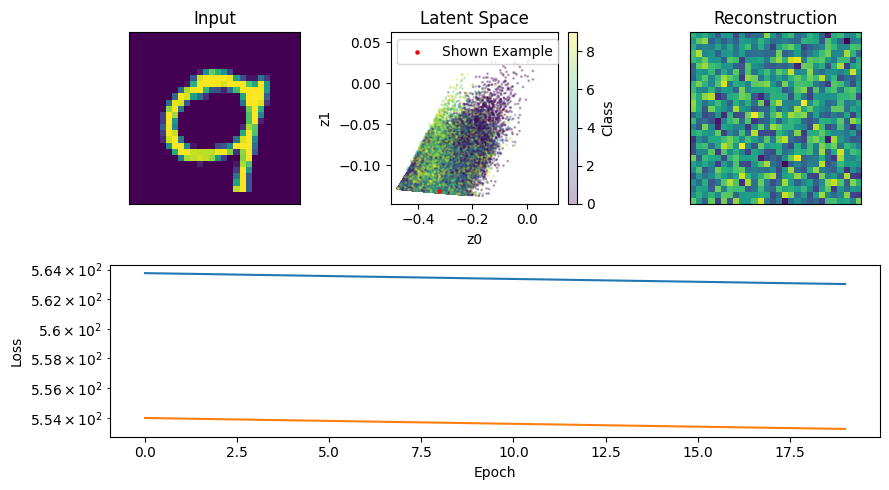

In [ ]:
#%%evaluate
idx = torch.randint(0, tr_data.size(0), (1,))
x_rec = model(tr_data.to(device))
z = model.encode(tr_data.to(device))

if device.type == "cuda":
    x_rec = x_rec.cpu()
    z = z.cpu()

fig = plt.figure(figsize=(9,5))
ax1 = fig.add_subplot(231, title="Input", xticks=[], yticks=[])
ax2 = fig.add_subplot(232, title="Latent Space", xlabel="z0", ylabel="z1")
ax3 = fig.add_subplot(233, title="Reconstruction", xticks=[], yticks=[])
ax4 = fig.add_subplot(212, xlabel="Epoch", ylabel="Loss", yscale="log")
im = ax1.imshow(tr_data[idx].reshape(28,28))
sctr = ax2.scatter(*z.detach().T, c=labels, alpha=0.3, s=1)
ax2.scatter(*z[idx].detach().T, c="red", s=5, label="Shown Example")
im = ax3.imshow(x_rec[idx].detach().reshape(28,28))
cbar = fig.colorbar(sctr, ax=ax2)
cbar.set_label("Class")
ax4.plot(loss_tr)
ax4.plot(loss_va)

ax2.legend(loc="upper left")

fig.tight_layout()
plt.show()

In [ ]:
#%%animate evolution of latent space
fig = plt.figure()
ax = fig.add_subplot(111, title=f"Epoch {1}", xlabel="z0", ylabel="z1")
cmap = ax.scatter(*latent_space[0].detach().T, c=val_labels, alpha=0.3, s=3)
cmap = fig.colorbar(cmap, ax=ax)
cmap.set_label("Class")

def update(frame):
    ax.clear()
    ax.set_title(f"Epoch {frame+1}")
    ax.set_xlabel("z0")
    ax.set_ylabel("z1")
    ax.scatter(*latent_space[frame].detach().T, c=val_labels, alpha=0.3, s=3)

anim = manimation.FuncAnimation(fig, update, frames=nepochs, interval=200)
anim.save(fn.replace(".csv", ".gif"))
rc("animation", html="jshtml")
display(anim)


In [ ]:
#%%save
df = pl.DataFrame({"epoch":range(nepochs), "loss_tr":loss_tr, "loss_va":loss_va, "duration":duration})
df.write_csv(fn)
df

epoch,loss_tr,loss_va,duration
i64,f64,f64,f64
0,563.765271,554.00255,0.389781
1,563.727396,553.963,0.396568
2,563.68813,553.92365,0.577314
3,563.646969,553.88435,0.480834
4,563.608286,553.8452,0.490426
…,…,…,…
15,563.178475,553.4214,0.356872
16,563.138236,553.3836,0.361905
17,563.0982,553.3459,0.358075
